/home/pavankumar/.local/lib/python3.10/site-packages/matplotlib/animation.py:880: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


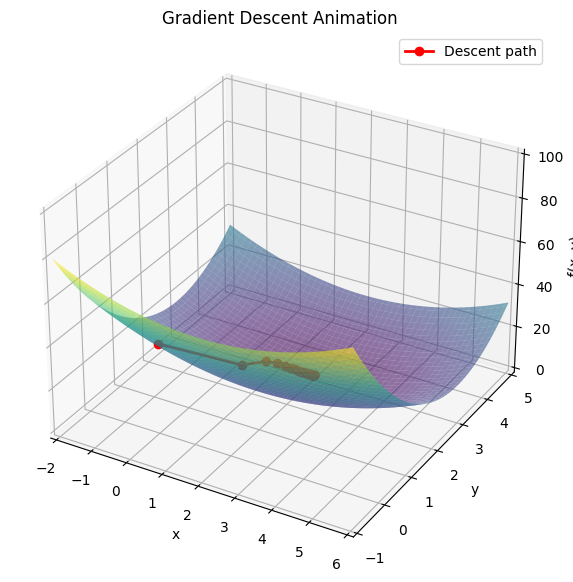

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import FuncAnimation

def func(x, y):
    return x**2 + 4*y**2 - 4*x - 24*y + 40

def grad(x, y):
    return np.array([2*x - 4, 8*y - 24])

# Gradient Descent
r0 = np.array([0.0, 0.0])
eta = 0.1
eps = 1e-5
path = [r0.copy()]
error = 10

while error > eps:
    r1 = r0 - eta * grad(r0[0], r0[1])
    error = np.linalg.norm(r1 - r0)
    path.append(r1.copy())
    r0 = r1

path = np.array(path)
z_path = func(path[:, 0], path[:, 1])

# Set up the surface
x = np.linspace(-2, 6, 100)
y = np.linspace(-1, 5, 100)
X, Y = np.meshgrid(x, y)
Z = func(X, Y)

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6)
line, = ax.plot([], [], [], 'r-o', label='Descent path', lw=2)

ax.set_xlim(-2, 6)
ax.set_ylim(-1, 5)
ax.set_zlim(0, 100)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('f(x, y)')
ax.set_title('Gradient Descent Animation')
ax.legend()

# Animation function
def update(i):
    line.set_data(path[:i+1, 0], path[:i+1, 1])
    line.set_3d_properties(z_path[:i+1])
    return line,

ani = FuncAnimation(fig, update, frames=len(path), interval=300, blit=False)

# To save the animation (uncomment if needed):
ani.save("gradient_descent_3d.mp4", writer="ffmpeg", fps=2)

plt.show()
